<a href="https://colab.research.google.com/github/192512041simats-hari/IOE-AND-AI-SYSTEM/blob/main/IOE_EXP_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 SMART COLD STORAGE LIVE MONITORING 
Units Processed    : 25/25
Elapsed Time       : 120 seconds



,Unit,Temperature (°C),Humidity (%),CO2 (ppm),Status
0,U01,-0.5,69,926,NORMAL
1,U02,9.9,80,476,ALERT
2,U03,-4.5,65,941,NORMAL
3,U04,-3.4,64,351,NORMAL
4,U05,4.6,77,823,NORMAL
5,U06,6.7,84,535,ALERT
6,U07,6.2,86,680,ALERT
7,U08,1.2,63,894,NORMAL
8,U09,-3.4,88,679,NORMAL
9,U10,-0.2,64,748,NORMAL



Normal Units       : 13
Alert Units        : 12

🚨 COLD STORAGE ALERT 🚨


,Unit,Temperature (°C),Humidity (%),CO2 (ppm),Status
1,U02,9.9,80,476,ALERT
5,U06,6.7,84,535,ALERT
6,U07,6.2,86,680,ALERT
12,U13,0.6,61,1180,ALERT
14,U15,8.0,87,868,ALERT
15,U16,8.0,85,438,ALERT
17,U18,6.8,70,1037,ALERT
20,U21,0.0,66,1054,ALERT
21,U22,7.6,69,1058,ALERT
22,U23,-4.4,83,1067,ALERT


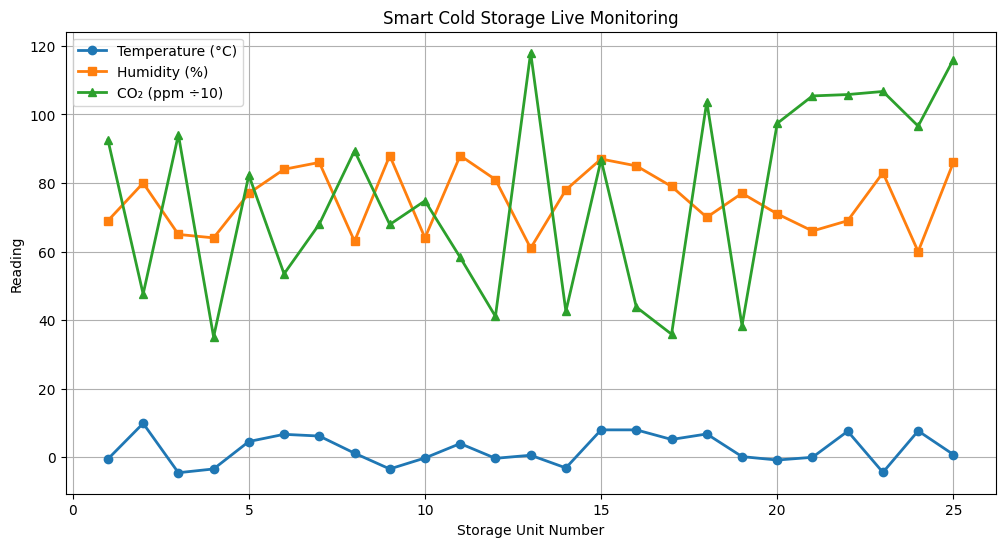



MONITORING COMPLETED SUCCESSFULLY


,Unit,Temperature (°C),Humidity (%),CO2 (ppm),Status
0,U01,-0.5,69,926,NORMAL
1,U02,9.9,80,476,ALERT
2,U03,-4.5,65,941,NORMAL
3,U04,-3.4,64,351,NORMAL
4,U05,4.6,77,823,NORMAL
5,U06,6.7,84,535,ALERT
6,U07,6.2,86,680,ALERT
7,U08,1.2,63,894,NORMAL
8,U09,-3.4,88,679,NORMAL
9,U10,-0.2,64,748,NORMAL



CSV file saved as Smart_Cold_Storage_Report.csv


In [1]:

# ==========================================================
# SMART COLD STORAGE LIVE MONITORING SYSTEM
# ==========================================================

import random
import time
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

# ==========================================================
# SETTINGS
# ==========================================================

TOTAL_UNITS = 25             # Total number of storage units
UPDATE_INTERVAL = 5          # Seconds between units

# ==========================================================
# STORAGE LISTS
# ==========================================================

unit_ids = []
temperatures = []
humidity_values = []
co2_values = []
status_list = []
time_axis = []

# ==========================================================
# FUNCTION TO GENERATE UNIT DATA
# ==========================================================

def generate_unit():

    temperature = round(random.uniform(-5.0, 10.0), 1)   # °C
    humidity = random.randint(60, 95)                     # %
    co2 = random.randint(350, 1200)                       # ppm

    if temperature > 6 or humidity > 90 or co2 > 1000:
        status = "ALERT"
    else:
        status = "NORMAL"

    return temperature, humidity, co2, status

# ==========================================================
# LIVE GRAPH FUNCTION
# ==========================================================

def live_graph():

    plt.figure(figsize=(12,6))

    plt.plot(time_axis, temperatures, marker='o', linewidth=2, label="Temperature (°C)")
    plt.plot(time_axis, humidity_values, marker='s', linewidth=2, label="Humidity (%)")
    plt.plot(time_axis, [c/10 for c in co2_values], marker='^', linewidth=2, label="CO₂ (ppm ÷10)")

    plt.title("Smart Cold Storage Live Monitoring")
    plt.xlabel("Storage Unit Number")
    plt.ylabel("Reading")
    plt.grid(True)
    plt.legend()

    plt.show()

# ==========================================================
# LIVE MONITORING LOOP
# ==========================================================

for unit in range(1, TOTAL_UNITS + 1):

    temperature, humidity, co2, status = generate_unit()

    unit_ids.append(f"U{unit:02d}")
    temperatures.append(temperature)
    humidity_values.append(humidity)
    co2_values.append(co2)
    status_list.append(status)
    time_axis.append(unit)

    df = pd.DataFrame({
        "Unit": unit_ids,
        "Temperature (°C)": temperatures,
        "Humidity (%)": humidity_values,
        "CO2 (ppm)": co2_values,
        "Status": status_list
    })

    clear_output(wait=True)

    print("=" * 70)
    print(" SMART COLD STORAGE LIVE MONITORING ")
    print("=" * 70)

    print(f"Units Processed    : {unit}/{TOTAL_UNITS}")
    print(f"Elapsed Time       : {(unit-1)*UPDATE_INTERVAL} seconds\n")

    display(df)

    alert = df[df["Status"] == "ALERT"]

    print("\nNormal Units       :", len(df) - len(alert))
    print("Alert Units        :", len(alert))

    if len(alert) > 0:
        print("\n🚨 COLD STORAGE ALERT 🚨")
        display(alert)

    live_graph()

    if unit != TOTAL_UNITS:
        time.sleep(UPDATE_INTERVAL)

# ==========================================================
# FINAL REPORT
# ==========================================================

print("\n")
print("=" * 70)
print("MONITORING COMPLETED SUCCESSFULLY")
print("=" * 70)

final_df = pd.DataFrame({
    "Unit": unit_ids,
    "Temperature (°C)": temperatures,
    "Humidity (%)": humidity_values,
    "CO2 (ppm)": co2_values,
    "Status": status_list
})

display(final_df)

final_df.to_csv("Smart_Cold_Storage_Report.csv", index=False)

print("\nCSV file saved as Smart_Cold_Storage_Report.csv")